In [1]:
%matplotlib widget

In [35]:
import numpy as np
import emg3d 
import empymod as ep
from scipy.constants import mu_0
import matplotlib.pyplot as plt
import time


In [3]:
def FDEM1D(sgm, thk):
    """ 1D FDEM response 
        
    Parameters
    ----------
    sgm : array
           Array of electrical conductivities [S/m], len(sigma) = nlay

    thk : array
           Array of thicknesses [m], len(thk) = nlay - 1

    Freq : frequency of device [Hz]

    coilOrient : array of strings
                  coil orientations: 'H' for horizontal coplanar, 
                  'V' for vertical coplanar, 'P' for perpendicular

    coilSpacing : array
                    separations of the transmitter and receiver coils [m]

    height : float
                height of the device with respect to ground [m]

    Returns
    -------
    Array [OP, IP]

    """  
    # Set geometry
    Freq = 9000
    coilSpacing = [2, 4, 8]
    pcoilSpacing = [2.1, 4.1, 8.1]
    coilOrient = np.array(['H', 'V', 'P'])
    height = 0
    strength = np.pi

    # Source and receivers geometry [x, y, z]
    source    = [0, 0, -height]
    receivers = [coilSpacing, np.zeros(len(coilSpacing)), -height]    
    preceivers = [pcoilSpacing, np.zeros(len(pcoilSpacing)), -height]

    # Depth and resistivity
    res_air = 1e6
    res = np.hstack((res_air, 1/sgm))
    depth = np.hstack((0, np.cumsum(thk)))
    # Empty array to store responses
    OUT = []

    if any(coilOrient == 'H'):

        H_Hs = ep.dipole(source, receivers, depth, res, Freq, ab = 66, xdirect=None, 
                          verb=0, strength = strength)*(2j * np.pi * Freq * mu_0) 
        H_Hp = ep.dipole(source, receivers, depth=[], res=[res_air], freqtime = Freq,
                         ab = 66, verb=0, strength = strength)*(2j * np.pi * Freq * mu_0)   
        op = (H_Hs/H_Hp).imag.amp() 
        ip = (H_Hs/H_Hp).real.amp() 
        OUT.append([op, ip])

    if any(coilOrient == 'V'):
        V_Hs = ep.dipole(source, receivers, depth, res, Freq, ab =55, xdirect=None, 
                         verb=0, strength = strength)*(2j * np.pi * Freq * mu_0) 
        V_Hp = ep.dipole(source, receivers, depth=[], res=[res_air], freqtime=Freq, 
                         ab=55, verb=0, strength = strength)*(2j * np.pi * Freq * mu_0)
        op = (V_Hs/V_Hp).imag.amp() 
        ip = (V_Hs/V_Hp).real.amp() 
        OUT.append([op, ip])

    if any(coilOrient == 'P'):
        # Maybe put 0.1m in receiver offset
        P_Hs = ep.dipole(source, preceivers, depth, res, Freq, ab=46, xdirect=None, 
                         verb=0, strength = strength)*(2j * np.pi * Freq * mu_0) 
        P_Hp = ep.dipole(source, preceivers, depth=[], res=[res_air], freqtime= Freq,
                         ab=66, verb=0, strength = strength)*(2j * np.pi * Freq * mu_0) 
        op = (P_Hs/P_Hp).imag.amp() 
        ip = (P_Hs/P_Hp).real.amp() 

        OUT.append([op, ip])

    return np.array(OUT).ravel()  

In [36]:
def FDEM3D(model_sig, model_air, height = 0):
    """ Simulate Dualem842S in 3D """
    startTime = time.time()
    
    frequency = 9000 # Hertz
    offsets_H = np.array([2, 4, 8])
    offsets_V = offsets_H.copy()
    offsets_P = np.array([2.1, 4.1, 8.1])
    
    # Define sources geometry
    # source = [x, y, z, azimuth, dip]
    Hsource_coords = [0, 0, height, 0, 90]
    Vsource_coords = [0, 0, height, 90, 0]
   # Psource_coords = Hsource_coords
    
    # Define sources
    Hsource = emg3d.TxMagneticPoint(Hsource_coords)
    Vsource = emg3d.TxMagneticPoint(Vsource_coords)
   # Psource = emg3d.TxMagneticPoint(Psource_coords)
    
    # Solve Electrical fields
    print('Solving sources...')
    # Total field Hsource
    Efield_H = emg3d.solve_source(model = model_sig, source = Hsource, frequency = frequency)
    # Primary field Hsource
    Efield_H_p = emg3d.solve_source(model = model_air, source = Hsource, frequency = frequency)
    
    # Total field Vsource
    Efield_V = emg3d.solve_source(model = model_sig, source = Vsource, frequency = frequency)
    # Primary field Vsource
    Efield_V_p = emg3d.solve_source(model = model_air, source = Vsource, frequency = frequency)
    
    # Get magnetic fields
    print('getting magnetic fields...')
    # Total magnetic field Hsource
    Hfield_H = emg3d.get_magnetic_field(model = model_sig, efield = Efield_H)
    # Primary magnetic field Hsource
    Hfield_H_p = emg3d.get_magnetic_field(model = model_sig, efield = Efield_H_p)
    
    # Total magnetic field Vsource
    Hfield_V = emg3d.get_magnetic_field(model = model_sig, efield = Efield_V)
    # Primary magnetic field Vsource
    Hfield_V_p = emg3d.get_magnetic_field(model = model_air, efield = Efield_V_p)
    
    # Get fields at receivers
    print('magnetic field at receivers...')
    # For total field Hsource
    H_Hrec = Hfield_H.get_receiver((offsets_H, offsets_H*0, height, 0, 90))*(2j * np.pi * frequency * mu_0) 
    # For primary field Hsource
    H_Hrec_p = Hfield_H_p.get_receiver((offsets_H, offsets_H*0, height, 0, 90))*(2j * np.pi * frequency * mu_0) 
    # Secondary field Hsource
    H_Hrec_s = H_Hrec - H_Hrec_p
    
    # For total field Vsource
    H_Vrec = Hfield_V.get_receiver((offsets_V, offsets_V*0, height, 90, 0))*(2j * np.pi * frequency * mu_0) 
    # For primary field Vsource
    H_Vrec_p = Hfield_V_p.get_receiver((offsets_V, offsets_V*0, height, 90, 0))*(2j * np.pi * frequency * mu_0) 
    # Secondary field Vsource
    H_Vrec_s = H_Vrec - H_Vrec_p
    
    # For total field Psource
    H_Prec = Hfield_H.get_receiver((offsets_P, offsets_P*0, height, 0, 0))*(2j * np.pi * frequency * mu_0) 
    # For primary field Psource in xz direction
    H_Prec_p_xz = Hfield_H_p.get_receiver((offsets_P, offsets_P*0, height, 0, 0))*(2j * np.pi * frequency * mu_0) 
    # Secondary field Psource
    H_Prec_s = H_Prec - H_Prec_p_xz
    # Primary field Psource in zz direction
    H_Prec_p = Hfield_H_p.get_receiver((offsets_P, offsets_P*0, height, 0, 90))*(2j * np.pi * frequency * mu_0) 
    
    # Calculate output components OP and IP
    print('getting output components')
    OUT = []
    # Horizontal coplanar
    op_h = (H_Hrec_s/H_Hrec_p).imag.amp()
    ip_h = (H_Hrec_s/H_Hrec_p).real.amp()
    OUT.append([op_h, ip_h])
    # Vertical coplanar
    op_v = (H_Vrec_s/H_Vrec_p).imag.amp()
    ip_v = (H_Vrec_s/H_Vrec_p).real.amp()
    OUT.append([op_v, ip_v])
    # Perpendicular
    op_p = (H_Prec_s/H_Prec_p).imag.amp()
    ip_p = (H_Prec_s/H_Prec_p).real.amp()
    OUT.append([op_p, ip_p])
    
    endTime = time.time()
    print('Done in', (endTime - startTime), 'seconds!')
    return np.array(OUT).ravel()
    

In [4]:
# Define model
sig = np.array([100/1000])
thk = np.array([])

sig_3d = np.hstack(([1/1e6], sig))
depth_3d = np.hstack(([0], -np.cumsum(thk)))

In [5]:
# Define source

height = 0
azi = 0
dip = 90
off = np.array([2,4,8])
src_coords = [0, 0, height, azi, dip]

# Define mesh
mesh = emg3d.construct_mesh(frequency = frequency,
                         properties = sig_3d,
                         center = [-0.125,-0.125,0],
                         mapping='Conductivity',
                         domain = ([-1, 10],[-4, 4],[-10,1]),
                         min_width_limits = 0.25,
                         center_on_edge=True)

# Define receivers
rec_coords = [off, np.zeros_like(off), height, azi, dip]

In [6]:
mesh

TensorMesh: 409,600 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     80       -107.66        150.35      0.25     33.69    1.31
   y     64       -110.81        151.03      0.25     40.22    1.37
   z     80       -121.38        112.38      0.25     25.49    1.29

In [7]:
# Populate grid

sig_x = np.ones(mesh.n_cells)*sig_3d[0]
sig_air = np.ones(mesh.n_cells)*sig_3d[0]
sig_x[mesh.cell_centers[:,2] <= depth_3d[0]] = sig_3d[1]
#sig_x[mesh.cell_centers[:,2] <= depth_3d[1]] = sig_3d[2]
#sig_x[mesh.cell_centers[:,2] <= depth_3d[2]] = sig_3d[3]

#x = (mesh.cell_centers[:,0] > 0) & (mesh.cell_centers[:,0] < 1)
#y = mesh.cell_centers[:,1] > 0
#z = (mesh.cell_centers[:,2] < -2) & (mesh.cell_centers[:,2] > -4)

#sig_x[x*y*z] = 200/1000

In [8]:
Model = emg3d.Model(mesh, 
                 property_x = sig_x,
                 mapping = 'Conductivity')

Model_air = emg3d.Model(mesh,
                     property_x = sig_air,
                     mapping = 'Conductivity')

In [9]:
#Model.interpolate_to_grid(new_grid)

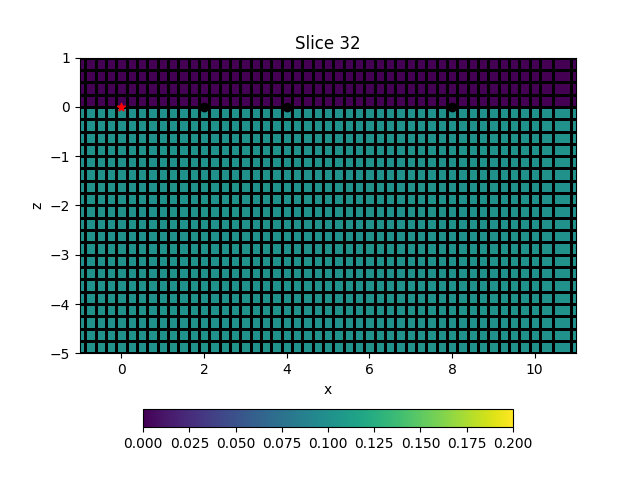

In [10]:
fig, ax = plt.subplots()

f0 = mesh.plot_slice(Model.property_x,
               normal = 'Y',
               v_type='CC',
               clim=[0,0.2],
               ax=ax,
               grid=True)
ax.set_xlim([-1,11])
ax.set_ylim([-5,1])
ax.scatter(src_coords[0], src_coords[2], c='r', marker = '*')
ax.scatter(rec_coords[0], rec_coords[1], c='k')

fig.colorbar(f0[0], ax=ax, orientation='horizontal', fraction=0.05)

# Calculate data

In [37]:
data_3D = FDEM3D(model_sig = Model,
                 model_air = Model_air)

Solving sources...
getting magnetic fields...
magnetic field at receivers...
getting output components
Done in 191.17801022529602 seconds!


In [38]:
data_1D = FDEM1D(sig, thk)

Text(0.5, 0, 'Data point')

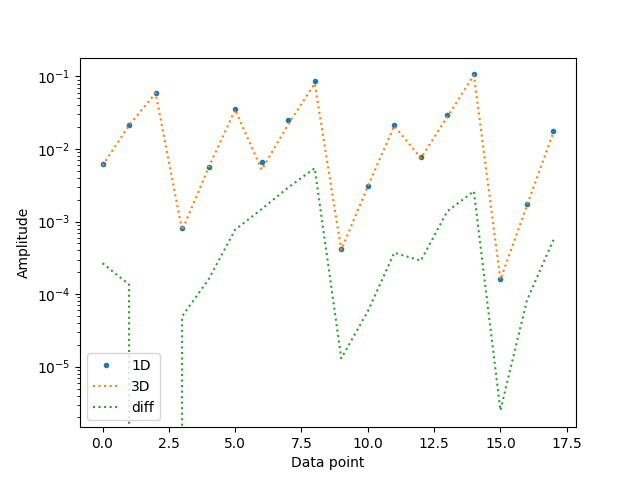

In [43]:
plt.figure()
plt.semilogy(data_1D, '.', label = '1D')
plt.semilogy(data_3D, ':', label = '3D')
plt.semilogy(data_1D - data_3D, ':', label = 'diff')
plt.legend()
plt.ylabel('Amplitude')
plt.xlabel('Data point')